# FULL Regression Analysis (Sentiment vs Key variables)v2.ipynb [JT]

<div class="alert alert-block alert-info">
Notebook Start

# Load and explore the data

In [1]:
# Import necessary libraries.
# Creating the linear regression
import numpy as np
import pandas as pd
import pylab as py
import sklearn

# Visualise the linear regression.
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scipy
from scipy import stats
from sklearn import metrics
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms
from statsmodels.graphics.gofplots import qqplot
import matplotlib.dates as mdates


# Import the statsmodels.
import statsmodels.api as sm 
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan

# Stationarity checks
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Tests for Normality (Jarque-Bera & Shapiro Wilks)
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import shapiro
import statsmodels.api as sm

C:\Anaconda\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
# Load the CSV file(s) as reviews.
variables = pd.read_csv('variables_transformed.csv')  

# Print the DataFrame.
variables.head() 

,Month / Year,Sentiment_LM,Sentiment_Finbert,Core_Inflation,Unemployment,Ave_Weekly_earnings_growth,GDP_growth,Benchmark_interest_rate,Economic_Inactivity rate,House_Price_index,Consumer_Confidence,FTSE100,GBP_USD
0,Sep-98,-0.24,-0.19,0.1,0.0,NaN,0.1,0.00,0.0,0.3,2,-3.59,2.90
1,Oct-98,-0.16,-0.21,-0.1,0.0,NaN,0.5,-0.25,0.0,1.0,-6,7.13,0.72
2,Nov-98,-0.32,-0.09,-0.1,-0.1,NaN,0.2,-0.50,-0.1,-0.1,2,7.20,-1.99
3,Dec-98,-0.35,-0.09,0.1,0.1,NaN,0.3,-0.50,0.0,-0.2,-1,0.65,0.58
4,Jan-99,-0.28,-0.29,0.0,0.0,NaN,0.2,-0.25,-0.2,0.7,5,0.23,-1.23


In [3]:
# Replace the missing values with 0 (if applicable)
variables.fillna(0, inplace=True)

In [4]:
# Print the DataFrame.
variables.head() 

,Month / Year,Sentiment_LM,Sentiment_Finbert,Core_Inflation,Unemployment,Ave_Weekly_earnings_growth,GDP_growth,Benchmark_interest_rate,Economic_Inactivity rate,House_Price_index,Consumer_Confidence,FTSE100,GBP_USD
0,Sep-98,-0.24,-0.19,0.1,0.0,0.0,0.1,0.00,0.0,0.3,2,-3.59,2.90
1,Oct-98,-0.16,-0.21,-0.1,0.0,0.0,0.5,-0.25,0.0,1.0,-6,7.13,0.72
2,Nov-98,-0.32,-0.09,-0.1,-0.1,0.0,0.2,-0.50,-0.1,-0.1,2,7.20,-1.99
3,Dec-98,-0.35,-0.09,0.1,0.1,0.0,0.3,-0.50,0.0,-0.2,-1,0.65,0.58
4,Jan-99,-0.28,-0.29,0.0,0.0,0.0,0.2,-0.25,-0.2,0.7,5,0.23,-1.23


In [5]:
# Determine the number of missing values.
variables.isna().sum()

Month / Year                  0
Sentiment_LM                  0
Sentiment_Finbert             0
Core_Inflation                0
Unemployment                  0
Ave_Weekly_earnings_growth    0
GDP_growth                    0
Benchmark_interest_rate       0
Economic_Inactivity rate      0
House_Price_index             0
Consumer_Confidence           0
FTSE100                       0
GBP_USD                       0
dtype: int64

In [6]:
# View the metadata.
variables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271 entries, 0 to 270
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Month / Year                271 non-null    object 
 1   Sentiment_LM                271 non-null    float64
 2   Sentiment_Finbert           271 non-null    float64
 3   Core_Inflation              271 non-null    float64
 4   Unemployment                271 non-null    float64
 5   Ave_Weekly_earnings_growth  271 non-null    float64
 6   GDP_growth                  271 non-null    float64
 7   Benchmark_interest_rate     271 non-null    float64
 8   Economic_Inactivity rate    271 non-null    float64
 9   House_Price_index           271 non-null    float64
 10  Consumer_Confidence         271 non-null    int64  
 11  FTSE100                     271 non-null    float64
 12  GBP_USD                     271 non-null    float64
dtypes: float64(11), int64(1), object(1)

In [7]:
# Basic descriptive statistics.
variables.describe()

,Sentiment_LM,Sentiment_Finbert,Core_Inflation,Unemployment,Ave_Weekly_earnings_growth,GDP_growth,Benchmark_interest_rate,Economic_Inactivity rate,House_Price_index,Consumer_Confidence,FTSE100,GBP_USD
count,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000
mean,-0.176199,-0.078376,0.013653,-0.008856,2.732472,0.148708,-0.021218,-0.007011,0.499262,-0.158672,0.043911,-0.139483
std,0.166493,0.092386,0.244339,0.103615,1.925323,1.587051,0.172245,0.111831,0.802080,3.540337,4.023274,2.073115
min,-0.650000,-0.340000,-0.900000,-0.200000,-2.900000,-19.200000,-1.500000,-0.300000,-2.500000,-25.000000,-14.860000,-10.520000
25%,-0.280000,-0.130000,-0.100000,-0.100000,1.300000,-0.100000,0.000000,-0.100000,0.050000,-2.000000,-2.250000,-1.270000
50%,-0.190000,-0.070000,0.000000,0.000000,2.700000,0.200000,0.000000,0.000000,0.500000,0.000000,0.770000,-0.080000
75%,-0.080000,-0.030000,0.200000,0.000000,4.200000,0.500000,0.000000,0.100000,1.000000,2.000000,2.705000,1.175000
max,0.330000,0.170000,0.900000,0.400000,8.900000,9.300000,0.500000,0.500000,2.800000,10.000000,11.650000,6.160000


In [8]:
# Check shape
variables.shape

(271, 13)

In [9]:
# Convert 'Month-Year' to datetime for regression analysis
variables['Month / Year'] = pd.to_datetime(variables['Month / Year'], format='%b-%y')  
# '%b' = abbreviated month, '%y' = 2-digit year

In [10]:
# Keep Month / Year for reference
month_year = variables['Month / Year']

In [11]:
# Drop it from numeric calculations for Correlation Map
variables_LM = variables.drop(columns=['Month / Year', 'Sentiment_Finbert'])

### Determine Correlation 

In [12]:
# Compute correlation matrix
corr_matrix = variables_LM.corr()

In [13]:
# Determine correlation
variables_LM.corr()

,Sentiment_LM,Core_Inflation,Unemployment,Ave_Weekly_earnings_growth,GDP_growth,Benchmark_interest_rate,Economic_Inactivity rate,House_Price_index,Consumer_Confidence,FTSE100,GBP_USD
Sentiment_LM,1.000000,-0.020855,-0.149829,0.137050,-0.045459,0.096649,0.051166,0.146349,0.057452,0.058897,0.081767
Core_Inflation,-0.020855,1.000000,-0.033242,0.129116,0.075738,0.085671,0.075354,0.035959,0.011933,0.011501,-0.002032
Unemployment,-0.149829,-0.033242,1.000000,-0.073373,0.057138,-0.190075,-0.027753,-0.197502,0.010290,-0.064160,-0.060964
Ave_Weekly_earnings_growth,0.137050,0.129116,-0.073373,1.000000,-0.024580,0.157659,-0.031450,0.058991,-0.121008,-0.028487,-0.019323
GDP_growth,-0.045459,0.075738,0.057138,-0.024580,1.000000,0.116384,-0.132042,0.120659,0.427603,0.049348,0.092184
Benchmark_interest_rate,0.096649,0.085671,-0.190075,0.157659,0.116384,1.000000,0.025897,0.233253,-0.051700,0.025635,0.275813
Economic_Inactivity rate,0.051166,0.075354,-0.027753,-0.031450,-0.132042,0.025897,1.000000,0.049904,-0.029013,-0.121144,0.051009
House_Price_index,0.146349,0.035959,-0.197502,0.058991,0.120659,0.233253,0.049904,1.000000,0.113171,0.088954,0.167299
Consumer_Confidence,0.057452,0.011933,0.010290,-0.121008,0.427603,-0.051700,-0.029013,0.113171,1.000000,-0.016725,0.079883
FTSE100,0.058897,0.011501,-0.064160,-0.028487,0.049348,0.025635,-0.121144,0.088954,-0.016725,1.000000,0.083574


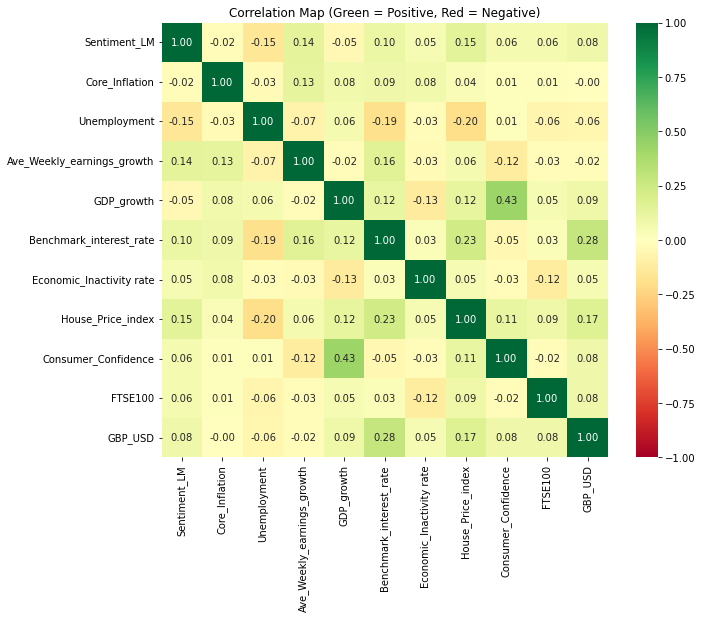

In [14]:
# Determine correlation
corr = variables_LM.corr()

# Create the correlation heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('Correlation Map (Green = Positive, Red = Negative)')
plt.show()

#### Key Correlations with Sentiment
- Sentiment_LM vs Unemployment (0.15)
- Sentiment_LM vs Ave.Weekly earnings growth 0.14
- Sentiment_LM vs Benchmark Interest rate 0.10
- Sentiment_LM vs House Price index 0.15

#### Other Correlations of Interest
- Core Inflation vs Ave.Weekly earnings growth 0.13
- Unemployment vs Benchmark Interest rate (0.19)
- Unemployment vs House Price index (0.20)
- Ave. Weekly earnings growth vs Benchmark interest rate 0.16
- Ave. Weekly earnings growth vs Consumer Confidence (0.12)
- GDP Growth vs Consumer Confidence 0.43
- GDP Growth vs Benchmark Interest rate 0.12
- GDP Growth vs Economic Inactivity rate (0.13)
- GDP Growth vs House Price Index 0.12
- Benchmark interest rate vs House Price index 0.23
- Benchmark interest rate vs GBP_USD 0.28
- Economic Inactivity rate vs FTSE100 (0.12)
- House Price Index vs Consumer Confidence 0.11
- House Price Index vs GBP_USD 0.17

### Check for Unit-root and Stationarity 

ADF Test - Null hypothesis H0: the series has a unit root → non-stationary

    -p-value < 0.05: reject H0 → stationary
    -p-value ≥ 0.05: fail to reject H0 → non-stationary

In [15]:
# Create Function for Stationarity checks for multiple variables
def check_stationarity_multi(df, lags=40):
    """
    Runs ADF test and ACF plot for all numeric columns in a dataframe.
    
    Parameters:
    df : pandas DataFrame
        DataFrame with numeric time series
    lags : int
        Number of lags for ACF plot
    """
    # Select numeric columns only
    numeric_cols = variables.select_dtypes(include=['float64', 'int64']).columns
    
    for col in numeric_cols:
        series = variables[col].dropna()  # remove missing values if any
        print(f"--- {col} ---")
        
        # Run ADF test
        adf_result = adfuller(series)
        print(f"ADF Statistic: {adf_result[0]:.4f}")
        print(f"p-value: {adf_result[1]:.4f}")
        print("Critical Values:")
        for key, value in adf_result[4].items():
            print(f"   {key}: {value:.4f}")
        if adf_result[1] < 0.05:
            print("=> Likely stationary\n")
        else:
            print("=> Likely non-stationary\n")
        
               
        # Plot ACF
        plt.figure(figsize=(10,4))
        plot_acf(series, lags=lags)
        plt.title(f'ACF Plot of {col}')
        plt.show()


--- Sentiment_LM ---
ADF Statistic: -4.8836
p-value: 0.0000
Critical Values:
   1%: -3.4551
   5%: -2.8724
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

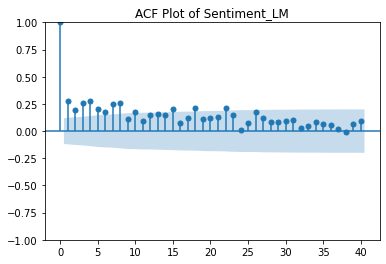

--- Sentiment_Finbert ---
ADF Statistic: -5.1294
p-value: 0.0000
Critical Values:
   1%: -3.4551
   5%: -2.8724
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

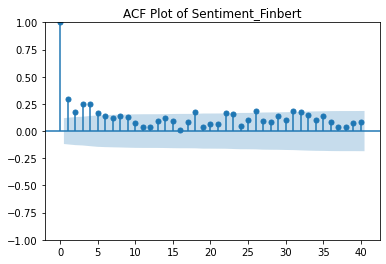

--- Core_Inflation ---
ADF Statistic: -18.0092
p-value: 0.0000
Critical Values:
   1%: -3.4548
   5%: -2.8723
   10%: -2.5725
=> Likely stationary



<Figure size 720x288 with 0 Axes>

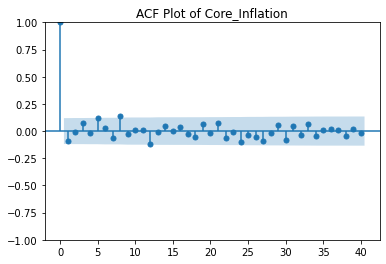

--- Unemployment ---
ADF Statistic: -5.7570
p-value: 0.0000
Critical Values:
   1%: -3.4550
   5%: -2.8724
   10%: -2.5725
=> Likely stationary



<Figure size 720x288 with 0 Axes>

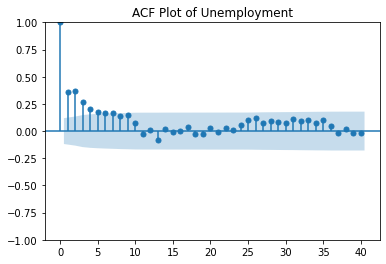

--- Ave_Weekly_earnings_growth ---
ADF Statistic: -2.9513
p-value: 0.0397
Critical Values:
   1%: -3.4551
   5%: -2.8724
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

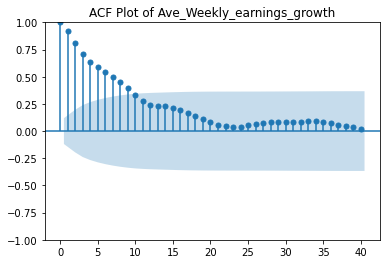

--- GDP_growth ---
ADF Statistic: -10.1450
p-value: 0.0000
Critical Values:
   1%: -3.4552
   5%: -2.8725
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

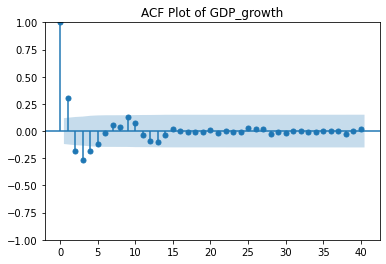

--- Benchmark_interest_rate ---
ADF Statistic: -6.5053
p-value: 0.0000
Critical Values:
   1%: -3.4549
   5%: -2.8723
   10%: -2.5725
=> Likely stationary



<Figure size 720x288 with 0 Axes>

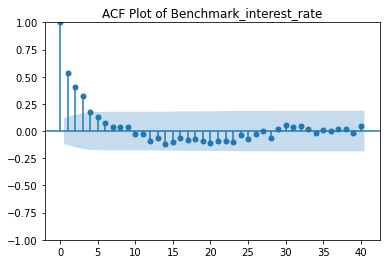

--- Economic_Inactivity rate ---
ADF Statistic: -4.4104
p-value: 0.0003
Critical Values:
   1%: -3.4556
   5%: -2.8726
   10%: -2.5727
=> Likely stationary



<Figure size 720x288 with 0 Axes>

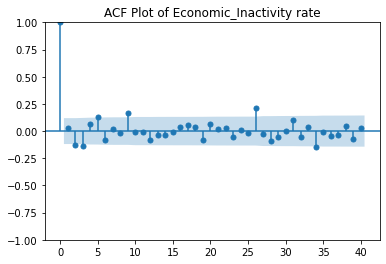

--- House_Price_index ---
ADF Statistic: -3.2092
p-value: 0.0195
Critical Values:
   1%: -3.4552
   5%: -2.8725
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

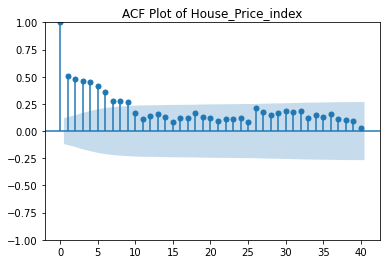

--- Consumer_Confidence ---
ADF Statistic: -17.6852
p-value: 0.0000
Critical Values:
   1%: -3.4548
   5%: -2.8723
   10%: -2.5725
=> Likely stationary



<Figure size 720x288 with 0 Axes>

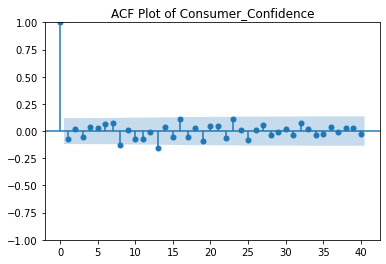

--- FTSE100 ---
ADF Statistic: -16.2089
p-value: 0.0000
Critical Values:
   1%: -3.4548
   5%: -2.8723
   10%: -2.5725
=> Likely stationary



<Figure size 720x288 with 0 Axes>

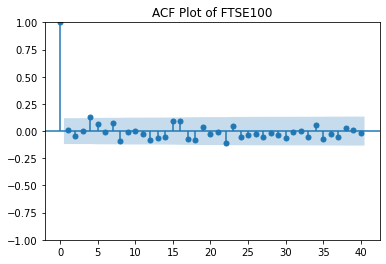

--- GBP_USD ---
ADF Statistic: -7.3110
p-value: 0.0000
Critical Values:
   1%: -3.4552
   5%: -2.8725
   10%: -2.5726
=> Likely stationary



<Figure size 720x288 with 0 Axes>

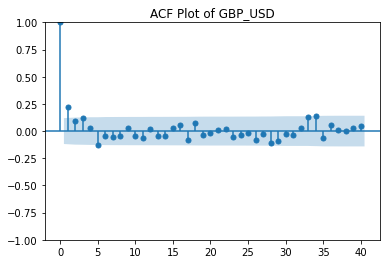

In [16]:
# Check for Stationarity
check_stationarity_multi(variables)

# Null hypothesis H0: the series has a unit root → non-stationary
        # p-value < 0.05: reject H0 → stationary
        # p-value ≥ 0.05: fail to reject H0 → non-stationary

All variables are Stationary - therefore ok to proceed with modelling, forecasting & testing hypothesis for Regression analysis

## Sentiment (LM) vs Core Inflation

In [17]:
# Define the dependent variable.
y = variables['Sentiment_LM'] 

# Define the independent variable.
x = variables['Core_Inflation'] 

# Note: Core_Inflation First Difference needs to be used to ensure Stationarity

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3482134459.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


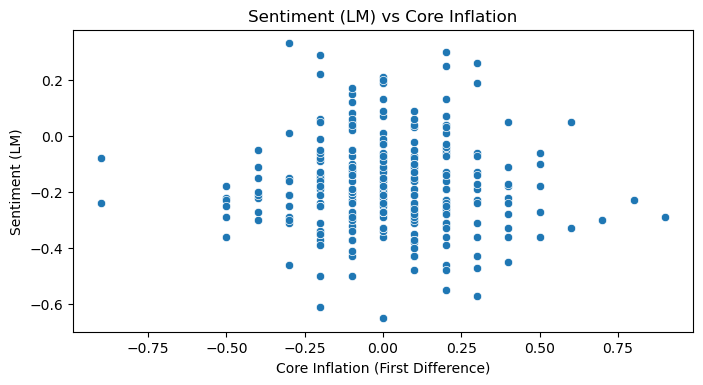

In [18]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment (LM) vs Core Inflation")
plt.xlabel("Core Inflation (First Difference)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "Core_Inflation",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [19]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg = np.polyfit(variables['Core_Inflation'], variables ['Sentiment_LM'], deg = 1)

# View output.
reg

array([-0.0142103 , -0.17600525])

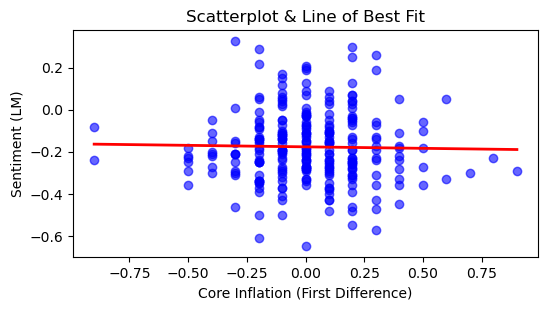

In [20]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend = np.polyval(reg, variables['Core_Inflation'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Core_Inflation',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Core Inflation (First Difference)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [21]:
# Pass linear regression through OLS methods.
test = ols('y ~ x', data = variables).fit(cov_type='HC1') 
# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1504
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.698
Time:                        07:12:31   Log-Likelihood:                 101.88
No. Observations:                 271   AIC:                            -199.8
Df Residuals:                     269   BIC:                            -192.5
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1760      0.010    -17.420      0.000      -0.196      -0.156
x             -0.0142      0.037     -0.388      0.698      -0.086       0.058
==============================================================================
Omnibus:                        8.423   Durbin-Watson:                   1.452
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                8.492
Skew:                           0.368   Prob(JB):                       0.0143
Kurtosis:                       3.459   Cond. No.                         4.10
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [22]:
# Extract Residuals
residuals = np.asarray(test.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Core Inflation) Breusch-Pagan test for testing for Heteroskedasticity 

In [23]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test = het_breuschpagan(test.resid, test.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results = dict(zip(labels, bp_test))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.5152
LM p-value: 0.4729
F Statistic: 0.5124
F p-value: 0.4747


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs Core Inflation) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

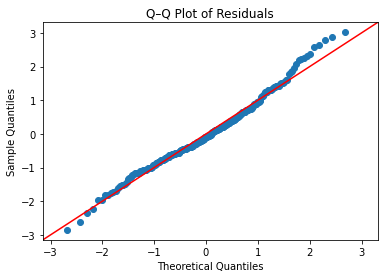

In [24]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild deviations in the tails.

In [25]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw1_p = shapiro(residuals)[1]
jb1_p = jarque_bera(residuals)[1]    
    
print("Shapiro–Wilks p-value:", shapiro(residuals)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals)[1])

Shapiro–Wilks p-value: 0.009719882552104629
Jarque–Bera p-value: 0.0143235469943858


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Unemployment

In [26]:
# Define the dependent variable.
y2 = variables['Sentiment_LM'] 

# Define the independent variable.
x2 = variables['Unemployment'] 

# Note: Unemployment needs to be First differenced since it is already expressed as a %

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3103200088.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


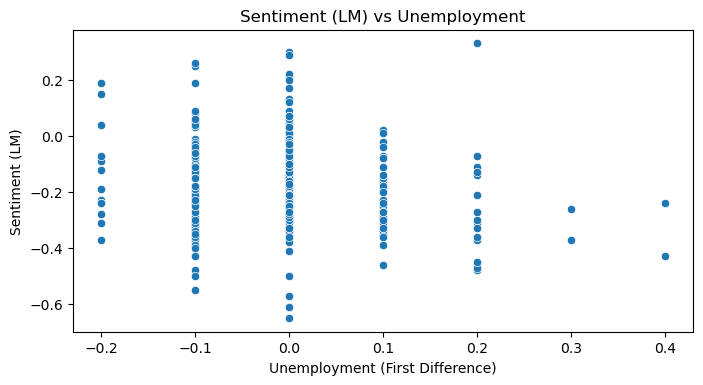

In [27]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment (LM) vs Unemployment")
plt.xlabel("Unemployment (First Difference)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "Unemployment",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [28]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg2 = np.polyfit(variables['Unemployment'], variables['Sentiment_LM'], deg = 1)

# View output.
reg2

array([-0.24075182, -0.17833138])

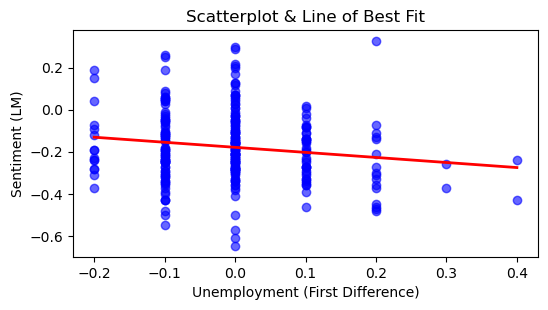

In [29]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend2 = np.polyval(reg2, variables['Unemployment'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Unemployment',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Unemployment (First Difference)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [30]:
# Pass linear regression through OLS methods.
test2 = ols('y2 ~ x2', data = variables).fit(cov_type='HC1')
# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y2   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     6.520
Date:                Sat, 22 Nov 2025   Prob (F-statistic):             0.0112
Time:                        07:13:01   Log-Likelihood:                 104.89
No. Observations:                 271   AIC:                            -205.8
Df Residuals:                     269   BIC:                            -198.6
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1783      0.010    -17.827      0.000      -0.198      -0.159
x2            -0.2408      0.094     -2.553      0.011      -0.426      -0.056
==============================================================================
Omnibus:                        9.296   Durbin-Watson:                   1.495
Prob(Omnibus):                  0.010   Jarque-Bera (JB):                9.888
Skew:                           0.363   Prob(JB):                      0.00713
Kurtosis:                       3.589   Cond. No.                         9.67
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [31]:
# Extract Residuals
residuals2 = np.asarray(test2.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Unemployment) Breusch-Pagan test for testing for Heteroskedasticity

In [32]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test2 = het_breuschpagan(test2.resid, test2.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results2 = dict(zip(labels, bp_test2))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results2.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.3462
LM p-value: 0.5563
F Statistic: 0.3441
F p-value: 0.5580


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs Unemployment) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

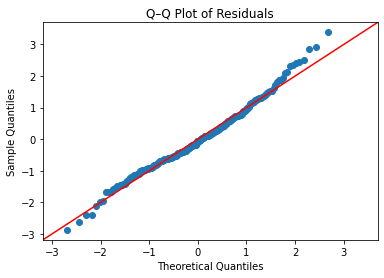

In [33]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals2, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild deviations in the tails.

In [34]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw2_p = shapiro(residuals2)[1]
jb2_p = jarque_bera(residuals2)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals2)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals2)[1])

Shapiro–Wilks p-value: 0.014510651901434966
Jarque–Bera p-value: 0.0071274838824738045


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Wages Growth (Ave_Weekly_earnings_growth)

In [35]:
# Define the dependent variable.
y3 = variables['Sentiment_LM'] 

# Define the independent variable.
x3 = variables['Ave_Weekly_earnings_growth']

# Note: Average Weekly earnings growth is already expressed as a MoM% growth rate. Therefore no further transformation needed
# Note: Average Weekly earnings growth is a proxy for Wages growth

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\2626320073.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


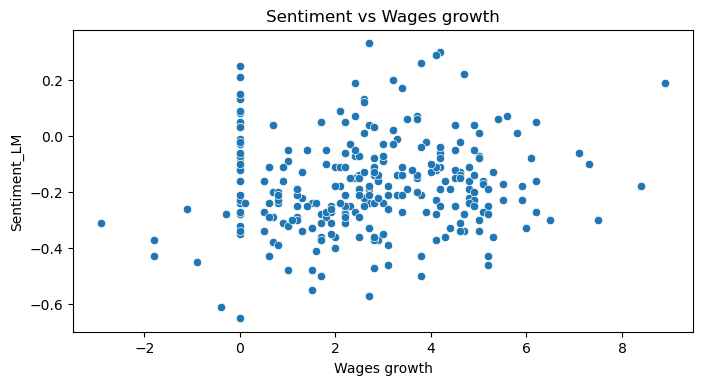

In [36]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs Wages growth")
plt.xlabel("Wages growth")
plt.ylabel("Sentiment_LM")
sns.scatterplot(data=variables,
               x= "Ave_Weekly_earnings_growth",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [37]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg3 = np.polyfit(variables['Ave_Weekly_earnings_growth'], variables['Sentiment_LM'], deg = 1)

# View output
reg3

array([ 0.01185143, -0.20858297])

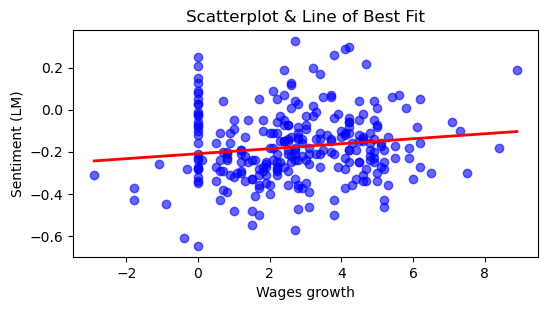

In [38]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend3 = np.polyval(reg3, variables['Ave_Weekly_earnings_growth'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Ave_Weekly_earnings_growth',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Wages growth")
plt.ylabel("Sentiment (LM)")
plt.show()

In [39]:
# Pass linear regression through OLS methods.
test3 = ols('y3 ~ x3', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y3   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     4.741
Date:                Sat, 22 Nov 2025   Prob (F-statistic):             0.0303
Time:                        07:13:27   Log-Likelihood:                 104.39
No. Observations:                 271   AIC:                            -204.8
Df Residuals:                     269   BIC:                            -197.6
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2086      0.019    -11.004      0.000      -0.246      -0.171
x3             0.0119      0.005      2.177      0.029       0.001       0.023
==============================================================================
Omnibus:                       10.352   Durbin-Watson:                   1.474
Prob(Omnibus):                  0.006   Jarque-Bera (JB):               10.562
Skew:                           0.428   Prob(JB):                      0.00509
Kurtosis:                       3.448   Cond. No.                         6.17
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [40]:
# Extract Residuals
residuals3 = np.asarray(test3.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Wages Growth) Breusch-Pagan test for testing for Heteroskedasticity

In [41]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test3 = het_breuschpagan(test3.resid, test3.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results3 = dict(zip(labels, bp_test3))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results3.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 1.8835
LM p-value: 0.1699
F Statistic: 1.8827
F p-value: 0.1712


p-values suggest no Heteroskedasticity.

###### (Sentiment (LM) vs Wages Growth) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

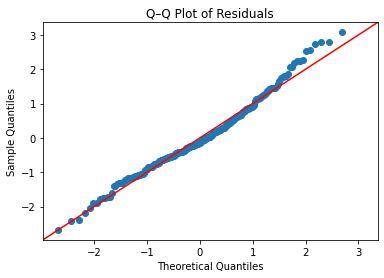

In [42]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals3, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild deviations in the tails

In [43]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw3_p = shapiro(residuals3)[1]
jb3_p = jarque_bera(residuals3)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals3)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals3)[1])

Shapiro–Wilks p-value: 0.0025203745663668403
Jarque–Bera p-value: 0.005087320851689499


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs GDP Growth

In [44]:
# Define the dependent variable.
y4 = variables['Sentiment_LM'] 

# Define the independent variable.
x4 = variables['GDP_growth']

# Note: GDP growth is already expressed as a MoM% growth rate. Therefore, no further transformation needed.

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\1696518885.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


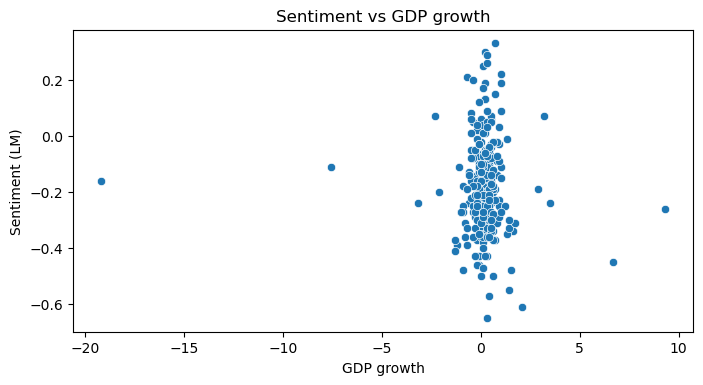

In [45]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs GDP growth")
plt.xlabel("GDP growth")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "GDP_growth",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [46]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg4 = np.polyfit(variables['GDP_growth'], variables['Sentiment_LM'], deg = 1)

# View output.
reg4

array([-0.00476897, -0.17549008])

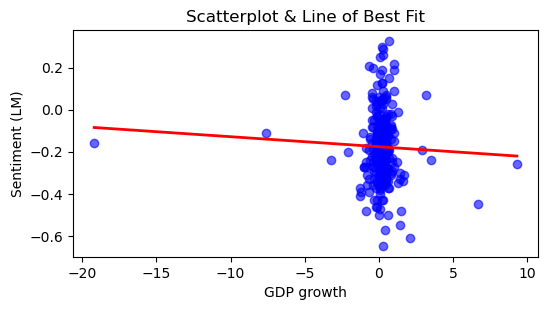

In [47]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend4 = np.polyval(reg4, variables['GDP_growth'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='GDP_growth',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("GDP growth")
plt.ylabel("Sentiment (LM)")
plt.show()

In [48]:
# Pass linear regression through OLS methods.
test4 = ols('y4 ~ x4', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y4   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                     1.192
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.276
Time:                        07:13:49   Log-Likelihood:                 102.10
No. Observations:                 271   AIC:                            -200.2
Df Residuals:                     269   BIC:                            -193.0
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1755      0.010    -17.464      0.000      -0.195      -0.156
x4            -0.0048      0.004     -1.092      0.275      -0.013       0.004
==============================================================================
Omnibus:                        8.808   Durbin-Watson:                   1.451
Prob(Omnibus):                  0.012   Jarque-Bera (JB):                8.909
Skew:                           0.380   Prob(JB):                       0.0116
Kurtosis:                       3.461   Cond. No.                         1.61
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [49]:
# Extract Residuals
residuals4 = np.asarray(test4.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs GDP Growth) Breusch-Pagan test for testing for Heteroskedasticity

In [50]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test4 = het_breuschpagan(test4.resid, test4.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results4 = dict(zip(labels, bp_test4))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results4.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 1.0764
LM p-value: 0.2995
F Statistic: 1.0727
F p-value: 0.3013


p-values suggest no Heteroskedasticity.

###### (Sentiment (LM) vs GDP Growth) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

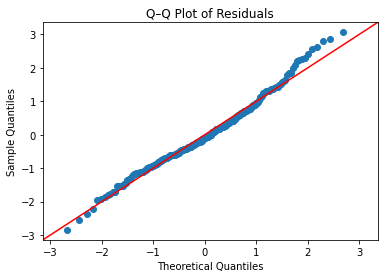

In [51]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals4, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild deviations in the tails

In [52]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw4_p = shapiro(residuals4)[1]
jb4_p = jarque_bera(residuals4)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals4)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals4)[1])

Shapiro–Wilks p-value: 0.009231100423286885
Jarque–Bera p-value: 0.011625959569578596


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Benchmark interest rate

In [53]:
# Define the dependent variable.
y5 = variables['Sentiment_LM'] 

# Define the independent variable.
x5 = variables['Benchmark_interest_rate']

# Note: Benchmark Interest rate needs to be first-differenced to ensure stationarity.

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3838342375.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


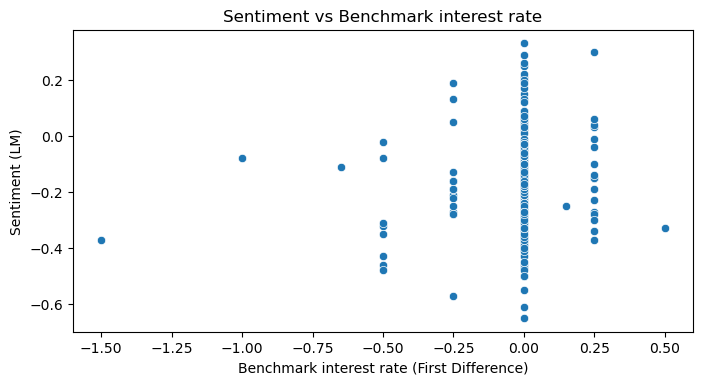

In [54]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs Benchmark interest rate")
plt.xlabel("Benchmark interest rate (First Difference)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "Benchmark_interest_rate",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [55]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg5 = np.polyfit(variables['Benchmark_interest_rate'], variables['Sentiment_LM'], deg = 1)

# View output.
reg5

array([ 0.09342169, -0.17421707])

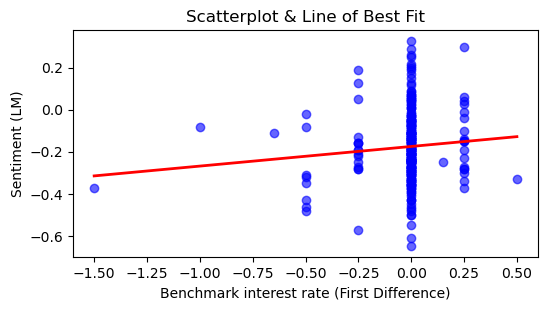

In [56]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend5 = np.polyval(reg5, variables['Benchmark_interest_rate'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Benchmark_interest_rate',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Benchmark interest rate (First Difference)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [57]:
# Pass linear regression through OLS methods.
test5 = ols('y5 ~ x5', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y5   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.016
Date:                Sat, 22 Nov 2025   Prob (F-statistic):             0.0836
Time:                        07:14:13   Log-Likelihood:                 103.09
No. Observations:                 271   AIC:                            -202.2
Df Residuals:                     269   BIC:                            -195.0
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1742      0.010    -17.159      0.000      -0.194      -0.154
x5             0.0934      0.054      1.737      0.082      -0.012       0.199
==============================================================================
Omnibus:                        8.366   Durbin-Watson:                   1.486
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                8.373
Skew:                           0.372   Prob(JB):                       0.0152
Kurtosis:                       3.433   Cond. No.                         5.82
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [58]:
# Extract Residuals
residuals5 = np.asarray(test5.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Benchmark Interest rate) Breusch-Pagan test for testing for Heteroskedasticity

In [59]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test5 = het_breuschpagan(test5.resid, test5.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results5 = dict(zip(labels, bp_test5))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results5.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.0010
LM p-value: 0.9747
F Statistic: 0.0010
F p-value: 0.9749


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs Benchmark Interest rate) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

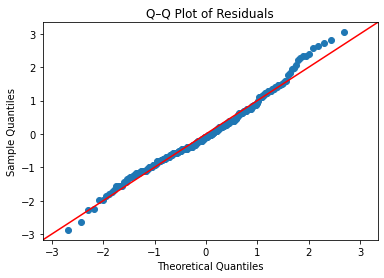

In [60]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals5, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild deviations in the tails

In [61]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw5_p = shapiro(residuals5)[1]
jb5_p = jarque_bera(residuals5)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals5)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals5)[1])

Shapiro–Wilks p-value: 0.009538288836215587
Jarque–Bera p-value: 0.015199114052325812


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Economic Inactivity rate

In [62]:
# Define the dependent variable.
y6 = variables['Sentiment_LM'] 

# Define the independent variable.
x6 = variables['Economic_Inactivity rate']

# Note: Economic Inactivity rate is already expressed as a %, therefore need to First Difference to ensure Stationarity

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3066018855.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


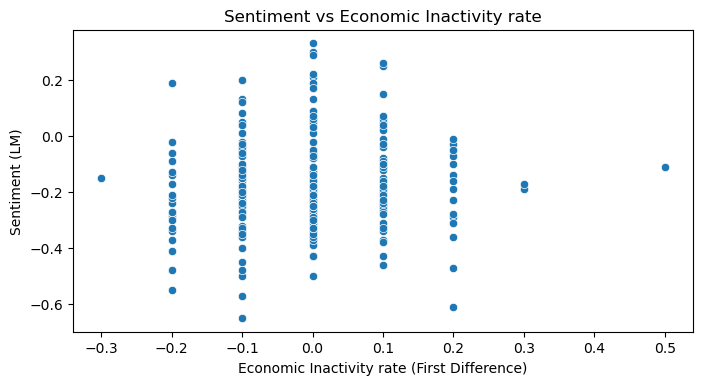

In [63]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs Economic Inactivity rate")
plt.xlabel("Economic Inactivity rate (First Difference)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "Economic_Inactivity rate",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [64]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg6 = np.polyfit(variables['Economic_Inactivity rate'], variables['Sentiment_LM'], deg = 1)

# View output.
reg6

array([ 0.07617585, -0.17566519])

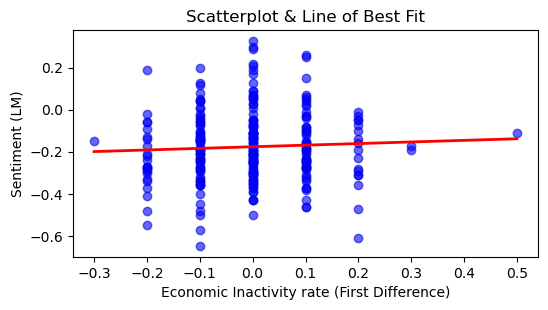

In [65]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend6 = np.polyval(reg6, variables['Economic_Inactivity rate'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Economic_Inactivity rate',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Economic Inactivity rate (First Difference)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [66]:
# Pass linear regression through OLS methods.
test6 = ols('y6 ~ x6', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y6   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8490
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.358
Time:                        07:14:41   Log-Likelihood:                 102.17
No. Observations:                 271   AIC:                            -200.3
Df Residuals:                     269   BIC:                            -193.1
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1757      0.010    -17.347      0.000      -0.196      -0.156
x6             0.0762      0.083      0.921      0.357      -0.086       0.238
==============================================================================
Omnibus:                        8.423   Durbin-Watson:                   1.454
Prob(Omnibus):                  0.015   Jarque-Bera (JB):                8.493
Skew:                           0.368   Prob(JB):                       0.0143
Kurtosis:                       3.460   Cond. No.                         8.96
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [67]:
# Extract Residuals
residuals6 = np.asarray(test6.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Economic Inactivity rate) Breusch-Pagan test for testing for Heteroskedasticity

In [68]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test6 = het_breuschpagan(test6.resid, test6.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results6 = dict(zip(labels, bp_test6))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results6.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.0225
LM p-value: 0.8809
F Statistic: 0.0223
F p-value: 0.8814


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs Economic Inactivity rate) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

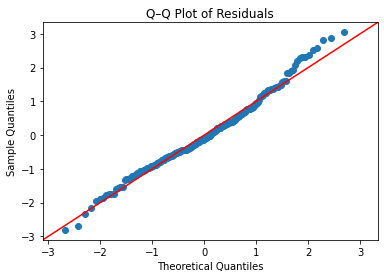

In [69]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals6, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that most of the residuals are normally distributed with some mild skewness in the tails

In [70]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw6_p = shapiro(residuals6)[1]
jb6_p = jarque_bera(residuals6)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals6)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals6)[1])

Shapiro–Wilks p-value: 0.009044629379681157
Jarque–Bera p-value: 0.01431512238445917


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs House Price index

In [71]:
# Define the dependent variable.
y7 = variables['Sentiment_LM'] 

# Define the independent variable.
x7 = variables['House_Price_index']

# Note: House Price Index is already a log-differenced growth rate. Therefore, no further transformation needed

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3261374738.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


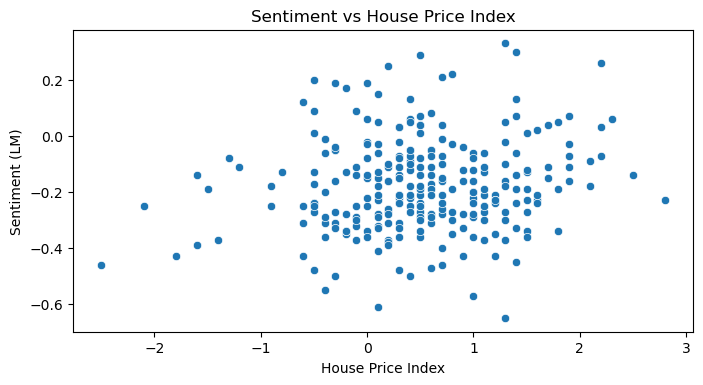

In [72]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs House Price Index")
plt.xlabel("House Price Index")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "House_Price_index",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [73]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg7 = np.polyfit(variables['House_Price_index'], variables['Sentiment_LM'], deg = 1)

# View output.
reg7

array([ 0.03037861, -0.19136615])

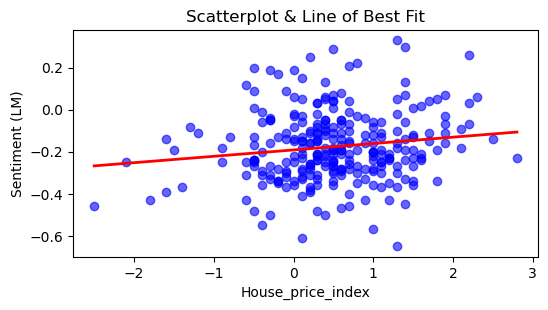

In [74]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend7 = np.polyval(reg7, variables['House_Price_index'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='House_Price_index',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("House_price_index")
plt.ylabel("Sentiment (LM)")
plt.show()

In [75]:
# Pass linear regression through OLS methods.
test7 = ols('y7 ~ x7', data = variables).fit(cov_type='HC1')

# Print the regression table.
test7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y7   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     6.223
Date:                Sat, 22 Nov 2025   Prob (F-statistic):             0.0132
Time:                        07:15:16   Log-Likelihood:                 104.75
No. Observations:                 271   AIC:                            -205.5
Df Residuals:                     269   BIC:                            -198.3
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1914      0.012    -16.328      0.000      -0.214      -0.168
x7             0.0304      0.012      2.495      0.013       0.007       0.054
==============================================================================
Omnibus:                        9.008   Durbin-Watson:                   1.540
Prob(Omnibus):                  0.011   Jarque-Bera (JB):                9.229
Skew:                           0.377   Prob(JB):                      0.00991
Kurtosis:                       3.499   Cond. No.                         1.81
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [76]:
# Extract Residuals
residuals7 = np.asarray(test7.resid).flatten()  # ensures 1-D NumPy array

###### (Sentiment (LM) vs House Price Index) Breusch-Pagan test for testing for Heteroskedasticity

In [77]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test7 = het_breuschpagan(test7.resid, test7.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results7 = dict(zip(labels, bp_test7))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results7.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.0000
LM p-value: 0.9953
F Statistic: 0.0000
F p-value: 0.9953


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs House Price Index) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

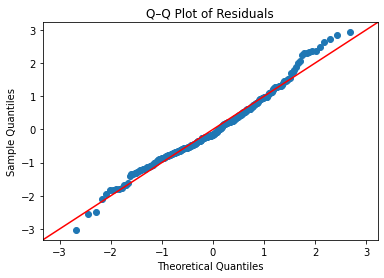

In [78]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals7, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that there are some slight skewness in the tails

In [79]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw7_p = shapiro(residuals7)[1]
jb7_p = jarque_bera(residuals7)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals7)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals7)[1])

Shapiro–Wilks p-value: 0.0027655102909529172
Jarque–Bera p-value: 0.009908728652515656


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs Consumer Confidence

In [80]:
# Define the dependent variable.
y8 = variables['Sentiment_LM'] 

# Define the independent variable.
x8 = variables['Consumer_Confidence']

# Note: Consumer Confidence is a bounded index and a measure of Sentiment. 
# This needs to be First Differenced to ensure Stationarity

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\527408892.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


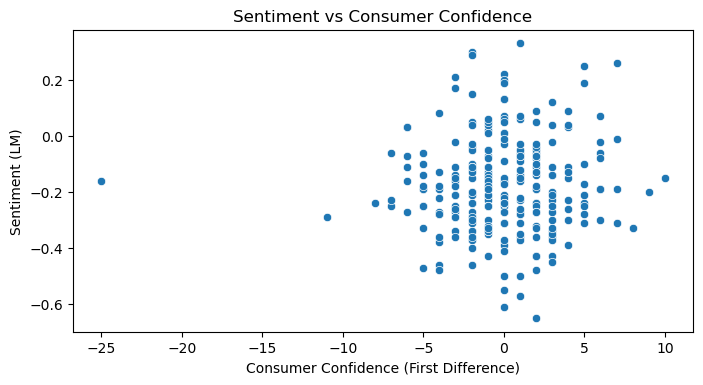

In [81]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs Consumer Confidence")
plt.xlabel("Consumer Confidence (First Difference)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "Consumer_Confidence",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [82]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg8 = np.polyfit(variables['Consumer_Confidence'], variables['Sentiment_LM'], deg = 1)

# View output.
reg8

array([ 0.00270182, -0.17577056])

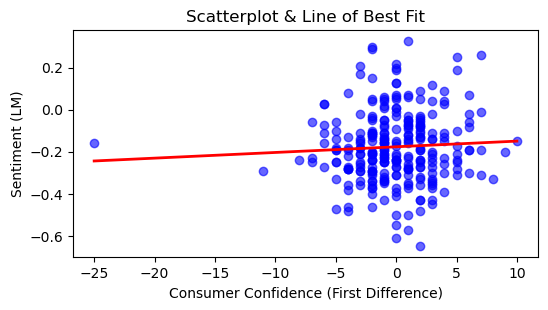

In [83]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend8 = np.polyval(reg8, variables['Consumer_Confidence'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='Consumer_Confidence',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("Consumer Confidence (First Difference)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [84]:
# Pass linear regression through OLS methods.
test8 = ols('y8 ~ x8', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test8.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y8   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     1.229
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.269
Time:                        07:16:04   Log-Likelihood:                 102.27
No. Observations:                 271   AIC:                            -200.5
Df Residuals:                     269   BIC:                            -193.3
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1758      0.010    -17.271      0.000      -0.196      -0.156
x8             0.0027      0.002      1.109      0.268      -0.002       0.007
==============================================================================
Omnibus:                        7.684   Durbin-Watson:                   1.453
Prob(Omnibus):                  0.021   Jarque-Bera (JB):                7.709
Skew:                           0.344   Prob(JB):                       0.0212
Kurtosis:                       3.459   Cond. No.                         3.54
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [85]:
# Extract Residuals
residuals8 = np.asarray(test8.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs Consumer Confidence) Breusch-Pagan test for testing for Heteroskedasticity

In [86]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test8 = het_breuschpagan(test8.resid, test8.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results8 = dict(zip(labels, bp_test8))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results8.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 1.5629
LM p-value: 0.2112
F Statistic: 1.5604
F p-value: 0.2127


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs Consumer Confidence) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

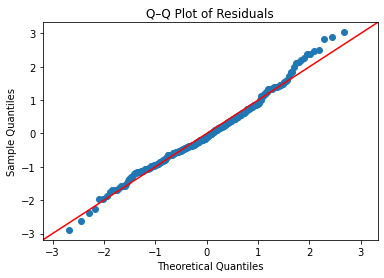

In [87]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals8, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that there are some slight skewness in the tails

In [88]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw8_p = shapiro(residuals8)[1]
jb8_p = jarque_bera(residuals8)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals8)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals8)[1])

Shapiro–Wilks p-value: 0.016270570429019957
Jarque–Bera p-value: 0.021181293023328104


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs FTSE100 index

In [89]:
# Define the dependent variable.
y9 = variables['Sentiment_LM'] 

# Define the independent variable.
x9 = variables['FTSE100']

# Note: FTSE100 index follows a 'random walk'. Therefore need to use Log-growth to ensure Stationarity

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\3881204621.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


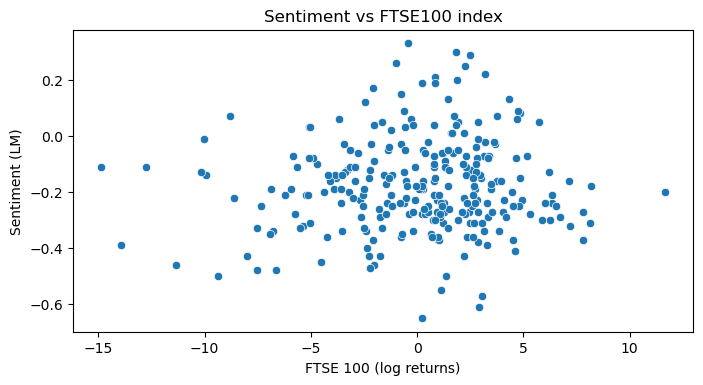

In [90]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs FTSE100 index")
plt.xlabel("FTSE 100 (log returns)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "FTSE100",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [91]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg9 = np.polyfit(variables['FTSE100'], variables['Sentiment_LM'], deg = 1)

# View output.
reg9

array([ 0.00243731, -0.17630629])

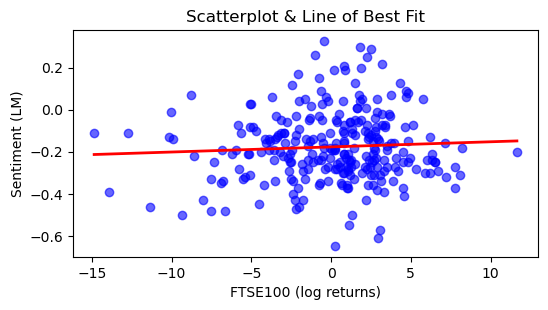

In [92]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend9 = np.polyval(reg9, variables['FTSE100'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='FTSE100',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("FTSE100 (log returns)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [93]:
# Pass linear regression through OLS methods.
test9 = ols('y9 ~ x9', data = variables).fit(cov_type='HC1')

# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust

# Print the regression table.
test9.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y9   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     1.083
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.299
Time:                        07:16:31   Log-Likelihood:                 102.29
No. Observations:                 271   AIC:                            -200.6
Df Residuals:                     269   BIC:                            -193.4
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1763      0.010    -17.432      0.000      -0.196      -0.156
x9             0.0024      0.002      1.041      0.298      -0.002       0.007
==============================================================================
Omnibus:                        8.061   Durbin-Watson:                   1.451
Prob(Omnibus):                  0.018   Jarque-Bera (JB):                8.023
Skew:                           0.365   Prob(JB):                       0.0181
Kurtosis:                       3.421   Cond. No.                         4.02
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [94]:
# Extract Residuals
residuals9 = np.asarray(test9.resid).flatten()  # ensures 1-D NumPy array

###### (Sentiment (LM) vs FTSE100) Breusch-Pagan test for testing for Heteroskedasticity

In [95]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test9 = het_breuschpagan(test9.resid, test9.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results9 = dict(zip(labels, bp_test9))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results9.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.0146
LM p-value: 0.9038
F Statistic: 0.0145
F p-value: 0.9043


p-values suggest no Heteroskedasticity.

###### (Sentiment (LM) vs FTSE100) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

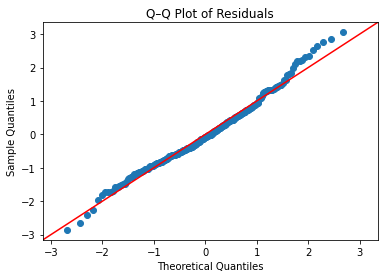

In [96]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals9, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that there are some slight skewness in the tails

In [97]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw9_p = shapiro(residuals9)[1]
jb9_p = jarque_bera(residuals9)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals9)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals9)[1])

Shapiro–Wilks p-value: 0.012328850448950423
Jarque–Bera p-value: 0.018109298657030197


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Sentiment (LM) vs GBP/USD

In [98]:
# Define the dependent variable.
y10 = variables['Sentiment_LM'] 

# Define the independent variable.
x10 = variables['GBP_USD']

# Note: GBP-USD Exchange rate follows a 'random walk'. Therefore need to use Log-growth to ensure Stationarity

C:\Users\Jai T\AppData\Local\Temp\ipykernel_752\2470601961.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=variables,


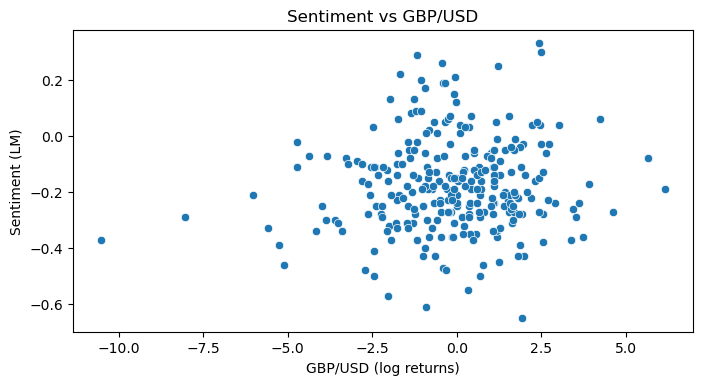

In [99]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Sentiment vs GBP/USD")
plt.xlabel("GBP/USD (log returns)")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables,
               x= "GBP_USD",
               y= "Sentiment_LM",
#               hue = "Color",
               palette = "dark")

plt.show()

In [100]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg10 = np.polyfit(variables['GBP_USD'], variables['Sentiment_LM'], deg = 1)

# View output.
reg10

array([ 0.00656672, -0.17528331])

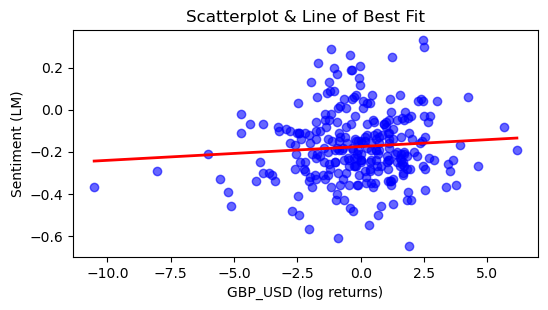

In [101]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend10 = np.polyval(reg10, variables['GBP_USD'])

# View the previous scatterplot.
plt.figure(figsize=(6, 3), dpi=100)
sns.regplot(
    data=variables,
    x='GBP_USD',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Scatterplot & Line of Best Fit")
plt.xlabel("GBP_USD (log returns)")
plt.ylabel("Sentiment (LM)")
plt.show()

In [102]:
# Pass linear regression through OLS methods.
test10 = ols('y10 ~ x10', data = variables).fit(cov_type='HC1')
# Apply White (1981) “HC1” function to ensure standard errors are Heteroskedasticity robust
 
# Print the regression table.
test10.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    y10   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2.275
Date:                Sat, 22 Nov 2025   Prob (F-statistic):              0.133
Time:                        07:19:24   Log-Likelihood:                 102.73
No. Observations:                 271   AIC:                            -201.5
Df Residuals:                     269   BIC:                            -194.2
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1753      0.010    -17.295      0.000      -0.195      -0.155
x10            0.0066      0.004      1.508      0.131      -0.002       0.015
==============================================================================
Omnibus:                        8.283   Durbin-Watson:                   1.435
Prob(Omnibus):                  0.016   Jarque-Bera (JB):                8.332
Skew:                           0.364   Prob(JB):                       0.0155
Kurtosis:                       3.455   Cond. No.                         2.08
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [103]:
# Extract Residuals
residuals10 = np.asarray(test10.resid).flatten()  # ensures 1-D NumPy array

##### (Sentiment (LM) vs GBP/USD) Breusch-Pagan test for testing for Heteroskedasticity

In [104]:
# BREUSCH–PAGAN TEST to test for Heteroskedasticity
    #p ≥ 0.05 → No heteroskedasticity (good)
    #p < 0.05 → Heteroskedasticity present (bad - need to use robust SEs)

# Perform the BP test
bp_test10 = het_breuschpagan(test10.resid, test10.model.exog)

# Extract results
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results10 = dict(zip(labels, bp_test10))

print("\nBreusch–Pagan Test Results:")
for key, value in bp_results10.items():
    print(f"{key}: {value:.4f}")


Breusch–Pagan Test Results:
LM Statistic: 0.0765
LM p-value: 0.7821
F Statistic: 0.0759
F p-value: 0.7831


p-values suggest no Heteroskedasticity.

##### (Sentiment (LM) vs GBP/USD) Q–Q Plot, Shapiro Wilks test & Jarque Bera test for Normality of Residuals

<Figure size 432x432 with 0 Axes>

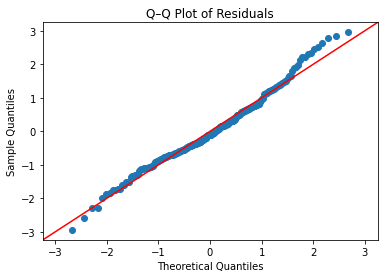

In [105]:
#Q–Q PLOT OF RESIDUALS
plt.figure(figsize=(6, 6))
sm.qqplot(residuals10, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

The Q-Q Plot shows that there are some skewness in the tails

In [106]:
# Normality tests
#1. Shapiro–Wilk Test ()
    #Null hypothesis (H₀): The data (residuals) are normally distributed.
    #Alternative hypothesis (H₁): The residuals are not normally distributed.

    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

#2. Jarque–Bera (JB) Test (Tests whether skewness and kurtosis of residuals match a normal distribution)
    # Null hypothesis (H₀): Residuals are normally distributed
    # Alternative hypothesis (H₁): Residuals are not normally distributed
    
    # p-value ≥ 0.05 Fail to reject H₀- Residuals are normally distributed
    # p-value < 0.05 Reject H₀ - residuals are not normally distributed 

sw10_p = shapiro(residuals10)[1]
jb10_p = jarque_bera(residuals10)[1]
    
print("Shapiro–Wilks p-value:", shapiro(residuals10)[1])
print("Jarque–Bera p-value:", jarque_bera(residuals10)[1])

Shapiro–Wilks p-value: 0.006951426851905259
Jarque–Bera p-value: 0.0155109529892002


The Shapiro Wilks & Jarque-Bera tests indicate that the residuals are not normally distributed

## Observations from Single Linear Regression

No evidence of heteroskedasticity for all variables. The variance of the residuals is constant across all variables. This means the regression assumption of homoskedasticity holds. Since heteroskedasticity is not present, the standard errors are valid

There is skewness and kurtosis evident in all variables. The tests for Normality indicate that the residuals for all variables are not Normally Distributed

##### Significant variables:
- Unemployment (p-value 0.011)
- Wages Growth (p-value 0.029)
- House Price Index (p-value 0.013)

## Multiple Linear Regression (Sentiment LM)

##### Define the variables

In [107]:
# Define the dependent variable.
yLM = variables['Sentiment_LM'] 

# Define the independent variable.
XLM = variables[['Core_Inflation', 'Unemployment','Ave_Weekly_earnings_growth','GDP_growth','Benchmark_interest_rate',
                'Economic_Inactivity rate','House_Price_index','Consumer_Confidence','FTSE100','GBP_USD']]

In [108]:
# Specify the model.
multi = LinearRegression()  

# Fit the model.
multi.fit(XLM, yLM)

LinearRegression()

In [109]:
# Call the predictions for X (array).
multi.predict(XLM)

array([-0.20190935, -0.2181946 , -0.20606224, -0.26263763, -0.20574459,
       -0.20358063, -0.16895108, -0.14514988, -0.20743167, -0.18245009,
       -0.17946147, -0.16493011, -0.21997353, -0.15410599, -0.15768604,
       -0.24302606, -0.19970021, -0.19900621, -0.18713967, -0.18966647,
       -0.20828254, -0.21237054, -0.25513424, -0.16134118, -0.19987559,
       -0.18478893, -0.21712613, -0.11938123, -0.10688764, -0.17213889,
       -0.12814571, -0.16686807, -0.1736751 , -0.14929566, -0.17485296,
       -0.15902709, -0.12756502, -0.08502752, -0.16133995, -0.17546685,
       -0.14867599, -0.12448196, -0.12580853, -0.14124211, -0.15306403,
       -0.11221393, -0.17403324, -0.18731433, -0.22515879, -0.15050003,
       -0.17559703, -0.18870418, -0.14463197, -0.16626866, -0.08527824,
       -0.14523972, -0.12838406, -0.1158675 , -0.14074041, -0.120347  ,
       -0.13379792, -0.1177985 , -0.16607447, -0.16205029, -0.13243304,
       -0.1642689 , -0.14782917, -0.1739921 , -0.155608  , -0.13

In [110]:
# Checking the value of R-squared, intercept and coefficients.
print("R-squared: ", multi.score(XLM, yLM))
print("Intercept: ", multi.intercept_)
print("Coefficients:")

list(zip(XLM, multi.coef_))

R-squared:  0.07273083259824775
Intercept:  -0.21582010595069387
Coefficients:


[('Core_Inflation', -0.03196988117680301),
 ('Unemployment', -0.1658520481781183),
 ('Ave_Weekly_earnings_growth', 0.011953311154225649),
 ('GDP_growth', -0.009956556582863065),
 ('Benchmark_interest_rate', 0.03735220810753502),
 ('Economic_Inactivity rate', 0.06762927652243715),
 ('House_Price_index', 0.019763882655465213),
 ('Consumer_Confidence', 0.004997924254972501),
 ('FTSE100', 0.0022973393218372637),
 ('GBP_USD', 0.003595116885966177)]

##### Training and testing subsets with MLR

In [111]:
# Create train and test data sets.
x_train, x_test, y_train, y_test = train_test_split(XLM, yLM,
                                                    test_size=0.3,
                                                    random_state=42)

In [112]:
# Training the model using the 'statsmodel' OLS library.
# Fit the model with the added constant.
model = sm.OLS(y_train, sm.add_constant(x_train)).fit(cov_type='HC1') 
# White (1981) “HC1” function to ensure Heteroskedasticity robust

# Set the predicted response vector.
Y_pred = model.predict(sm.add_constant(x_test)) 

# Call a summary of the model.
print_model = model.summary()

# Print the summary.
print(print_model)  

                            OLS Regression Results                            
Dep. Variable:           Sentiment_LM   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     3.115
Date:                Sat, 22 Nov 2025   Prob (F-statistic):            0.00110
Time:                        07:20:03   Log-Likelihood:                 87.829
No. Observations:                 189   AIC:                            -153.7
Df Residuals:                     178   BIC:                            -118.0
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

##### Variables of significance for LM model are:
 - GDP Growth (p-value 0.03)
 - Consumer confidence (p-value 0.019)
 - GBP-USD (p-value 0.016)
 - Ave. Weekly Earnings growth (0.057)

In [113]:
print(multi.score(x_train, y_train)*100) # Print the R-squared value

9.020303469669921


##### Run a regression test

In [114]:
# Run regression on the train subset.
mlr = LinearRegression()  

mlr.fit(x_train, y_train)

LinearRegression()

In [115]:
# Call the predictions for X in the train set.
y_pred_mlr = mlr.predict(x_train)  

# Print the predictions.
print("Prediction for test set: {}".format(y_pred_mlr)) 

Prediction for test set: [-0.0840304  -0.0792854  -0.12115495 -0.30678423 -0.18694666 -0.17673821
 -0.2187643  -0.34960075 -0.11838612 -0.16306066 -0.12914549 -0.19120163
 -0.21044109 -0.22759937 -0.11753017 -0.218559   -0.14790292 -0.14185132
 -0.24138591 -0.20272608 -0.14133293 -0.41933397 -0.24650268 -0.17555826
 -0.18205742 -0.24065467 -0.14600924 -0.17521332 -0.12805261 -0.21093684
 -0.14954849 -0.2109087  -0.17395062 -0.21477555 -0.08495527 -0.17746851
 -0.17395288 -0.15553038 -0.12710441 -0.24323474 -0.13396483 -0.14433171
 -0.3219754  -0.1630328  -0.16462353 -0.253195   -0.16871504 -0.12928379
 -0.18278583 -0.21149436 -0.14441589 -0.13815139 -0.21863494 -0.13553039
 -0.21952922 -0.19570703 -0.14412523 -0.26672765 -0.2041217  -0.21668972
 -0.20417823 -0.17801673 -0.18841477 -0.22024329 -0.19682334 -0.24962724
 -0.17500668 -0.13054285 -0.11921779 -0.2302846  -0.11480727 -0.13227854
 -0.16475203 -0.15773178 -0.1316655  -0.13241289 -0.23582756 -0.21364628
 -0.19462091 -0.18651489 -

In [116]:
# Print the R-squared value.
print(mlr.score(x_test, y_test)*100)  

-5.159469576036657


###### Check for multicollinearity

In [117]:
# import from statsmodels.stats.outliers_influence import variance_inflation_factor

# Check multicollinearity.
x_temp = sm.add_constant(x_train)

# Create an empty DataFrame. 
vif = pd.DataFrame()

# Calculate the VIF for each value.
vif['VIF Factor'] = [variance_inflation_factor(x_temp.values,
                                               i) for i in range(x_temp.values.shape[1])]

# Create the feature columns.
vif['features'] = x_temp.columns

# Print the values to one decimal points.
print(vif.round(1))

    VIF Factor                    features
0          3.7                       const
1          1.1              Core_Inflation
2          1.1                Unemployment
3          1.1  Ave_Weekly_earnings_growth
4          1.5                  GDP_growth
5          1.3     Benchmark_interest_rate
6          1.1    Economic_Inactivity rate
7          1.2           House_Price_index
8          1.4         Consumer_Confidence
9          1.1                     FTSE100
10         1.2                     GBP_USD


Variance Inflation factor for variables are < 5, so very little evidence of multi-collinearity. Coefficients are stable, Standard errors are not inflated, Significance tests are reliable and Model interpretation is safe

##### Evaluate the model

In [118]:
# Call the metrics.mean_absolute_error function.  
print('Mean Absolute Error (Final):', metrics.mean_absolute_error(y_test, Y_pred))  

# Call the metrics.mean_squared_error function.
print('Mean Square Error (Final):', metrics.mean_squared_error(y_test, Y_pred)) 

Mean Absolute Error (Final): 0.1477762312599453
Mean Square Error (Final): 0.03300274496795072


## Multiple Linear Regression (Sentiment Finbert)

##### Define the variables

In [119]:
# Define the dependent variable.
yFIN = variables['Sentiment_Finbert'] 

# Define the independent variable.
XFIN = variables[['Core_Inflation', 'Unemployment','Ave_Weekly_earnings_growth','GDP_growth','Benchmark_interest_rate',
                'Economic_Inactivity rate','House_Price_index','Consumer_Confidence','FTSE100','GBP_USD']]

In [120]:
# Specify the model.
multi = LinearRegression()  

# Fit the model.
multi.fit(XFIN, yFIN)

LinearRegression()

In [121]:
# Call the predictions for X (array).
multi.predict(XFIN)

array([-0.08309109, -0.08984636, -0.11573536, -0.14331355, -0.11312946,
       -0.11793254, -0.0628712 , -0.05270542, -0.10245825, -0.07427626,
       -0.05241655, -0.05007534, -0.06575568, -0.06584593, -0.04912012,
       -0.07709741, -0.07491166, -0.0755713 , -0.077653  , -0.06115115,
       -0.08260327, -0.08232758, -0.11171224, -0.05541398, -0.07197507,
       -0.08052017, -0.10596658, -0.05624173, -0.05902484, -0.10203008,
       -0.071698  , -0.07832907, -0.09420937, -0.10145818, -0.09485197,
       -0.11899747, -0.05715557, -0.03526944, -0.07458163, -0.07152822,
       -0.0728117 , -0.05959582, -0.07423806, -0.07229288, -0.0534044 ,
       -0.040935  , -0.06747361, -0.08874895, -0.10534855, -0.07005339,
       -0.08463287, -0.0984097 , -0.05491481, -0.07299766, -0.02501394,
       -0.04405563, -0.07203973, -0.0368442 , -0.06975631, -0.05065855,
       -0.03527781, -0.05236935, -0.06045168, -0.07310776, -0.05957641,
       -0.07728158, -0.06715688, -0.09030994, -0.07326989, -0.05

In [122]:
# Checking the value of R-squared, intercept and coefficients.
print("R-squared: ", multi.score(XFIN, yFIN))
print("Intercept: ", multi.intercept_)
print("Coefficients:")

list(zip(XFIN, multi.coef_))

R-squared:  0.10483433288253519
Intercept:  -0.08792564741695548
Coefficients:


[('Core_Inflation', -0.0020326993760793263),
 ('Unemployment', -0.11373618808375346),
 ('Ave_Weekly_earnings_growth', 0.0023090778603921088),
 ('GDP_growth', -4.9078355025050155e-06),
 ('Benchmark_interest_rate', 0.08690597673078561),
 ('Economic_Inactivity rate', 0.06656636830908584),
 ('House_Price_index', 0.010004634495226344),
 ('Consumer_Confidence', 0.0010753759920221141),
 ('FTSE100', 0.0020047659581654974),
 ('GBP_USD', 0.002442510900112374)]

##### Training and testing subsets with MLR

In [123]:
# Create train and test data sets.
x_train2, x_test2, y_train2, y_test2 = train_test_split(XFIN, yFIN,
                                                    test_size=0.3,
                                                    random_state=42)

In [124]:
# Training the model using the 'statsmodel' OLS library.
# Fit the model with the added constant.
model = sm.OLS(y_train2, sm.add_constant(x_train2)).fit(cov_type='HC1')
# White (1981) “HC1” function to ensure Heteroskedasticity robust

# Set the predicted response vector.
Y_pred2 = model.predict(sm.add_constant(x_test2)) 

# Call a summary of the model.
print_model = model.summary()

# Print the summary.
print(print_model)  

                            OLS Regression Results                            
Dep. Variable:      Sentiment_Finbert   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     3.190
Date:                Sat, 22 Nov 2025   Prob (F-statistic):           0.000859
Time:                        07:20:44   Log-Likelihood:                 208.96
No. Observations:                 189   AIC:                            -395.9
Df Residuals:                     178   BIC:                            -360.3
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

#### Variables of significance for Finbert model are:
- Benchmark Interest rate (p-value 0.033)
- Consumer Confidence (p-value 0.047)
- FTSE100 (p-value 0.052)
- GBP-USD (p-value 0.022)

In [125]:
print(multi.score(x_train2, y_train2)*100) # Print the R-squared value

12.715993397736302


##### Check for multicollinearity

In [126]:
# import from statsmodels.stats.outliers_influence import variance_inflation_factor

# Check multicollinearity.
x_temp2 = sm.add_constant(x_train2)

# Create an empty DataFrame. 
vif = pd.DataFrame()

# Calculate the VIF for each value.
vif['VIF Factor'] = [variance_inflation_factor(x_temp2.values,
                                               i) for i in range(x_temp2.values.shape[1])]

# Create the feature columns.
vif['features'] = x_temp2.columns

# Print the values to one decimal points.
print(vif.round(1))

    VIF Factor                    features
0          3.7                       const
1          1.1              Core_Inflation
2          1.1                Unemployment
3          1.1  Ave_Weekly_earnings_growth
4          1.5                  GDP_growth
5          1.3     Benchmark_interest_rate
6          1.1    Economic_Inactivity rate
7          1.2           House_Price_index
8          1.4         Consumer_Confidence
9          1.1                     FTSE100
10         1.2                     GBP_USD


Variance Inflation factor for variables are < 5, so very little evidence of multi-collinearity. Coefficients are stable, Standard errors are not inflated, Significance tests are reliable and Model interpretation is safe

##### Evaluate the model

In [127]:
# Call the metrics.mean_absolute_error function.  
print('Mean Absolute Error (Final):', metrics.mean_absolute_error(y_test2, Y_pred2))  

# Call the metrics.mean_squared_error function.
print('Mean Square Error (Final):', metrics.mean_squared_error(y_test2, Y_pred2)) 

Mean Absolute Error (Final): 0.08450894574064176
Mean Square Error (Final): 0.011300494844989144


#### The Finbert model has a lower MAE, lower MSE and higher Adjusted R-Squared than the LM Model. 

## Rolling Correlations 

### Sentiment (LM) vs Variables of interest

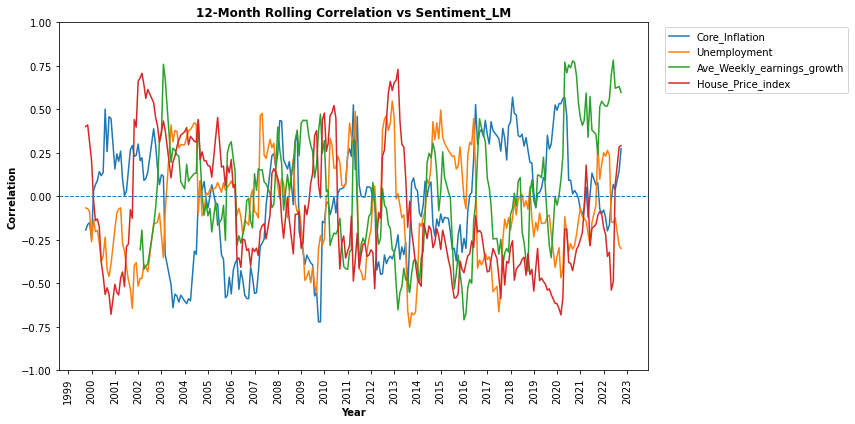

In [129]:
# Load the CSV 
variables = pd.read_csv('variables_transformed.csv')

# Convert Month-Year to datetime 
variables['Month / Year'] = pd.to_datetime(variables['Month / Year'], format='%b-%y')

# Set date as index so rolling correlation uses real time
variables = variables.set_index('Month / Year')

# Drop non-numeric column
variables_LM = variables.drop(columns=['Sentiment_Finbert'])

# Selected variables
selected_vars = [
    'Core_Inflation',
    'Unemployment',
    'Ave_Weekly_earnings_growth',
    'House_Price_index'
]

target = 'Sentiment_LM'
window = 12

plt.figure(figsize=(12, 6))

for col in selected_vars:
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col)

plt.title(f"{window}-Month Rolling Correlation vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


### Sentiment (LM) vs Unemployment

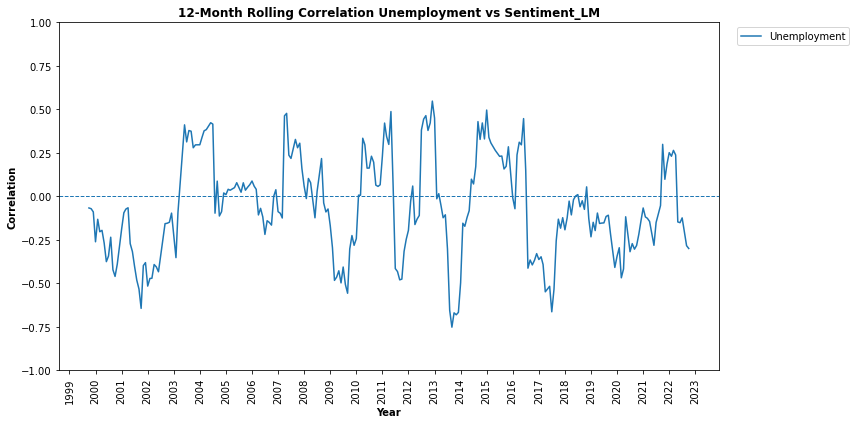

In [130]:
# Selected variables
selected_vars = [
    'Unemployment'
]

target = 'Sentiment_LM'
window = 12

plt.figure(figsize=(12, 6))

for col in selected_vars:
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col)

plt.title(f"{window}-Month Rolling Correlation Unemployment vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


### Sentiment (LM) vs Wages growth

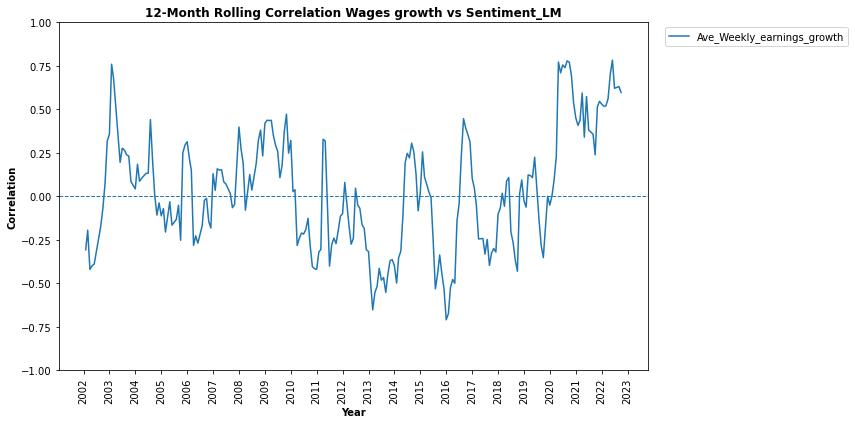

In [131]:
# Selected variables
selected_vars = [
    'Ave_Weekly_earnings_growth'
]

target = 'Sentiment_LM'
window = 12

plt.figure(figsize=(12, 6))

for col in selected_vars:
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col)

plt.title(f"{window}-Month Rolling Correlation Wages growth vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### Sentiment (LM) vs House Price Index

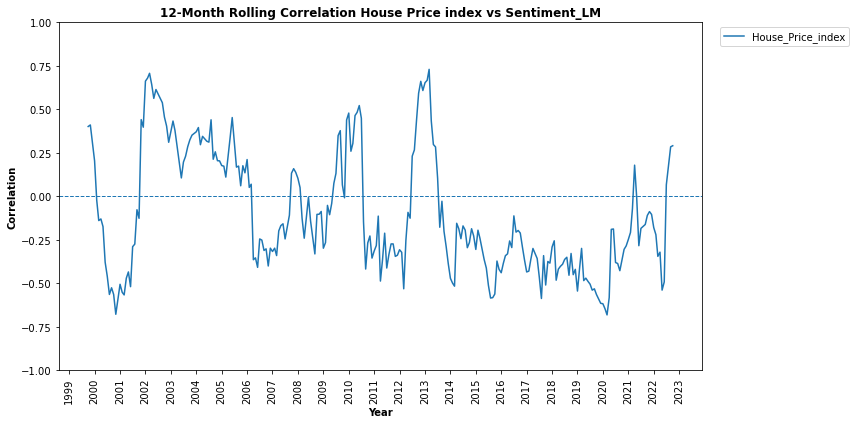

In [132]:
# Selected variables
selected_vars = [
    'House_Price_index'
]

target = 'Sentiment_LM'
window = 12

plt.figure(figsize=(12, 6))

for col in selected_vars:
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col)

plt.title(f"{window}-Month Rolling Correlation House Price index vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### Correlation with all three variables

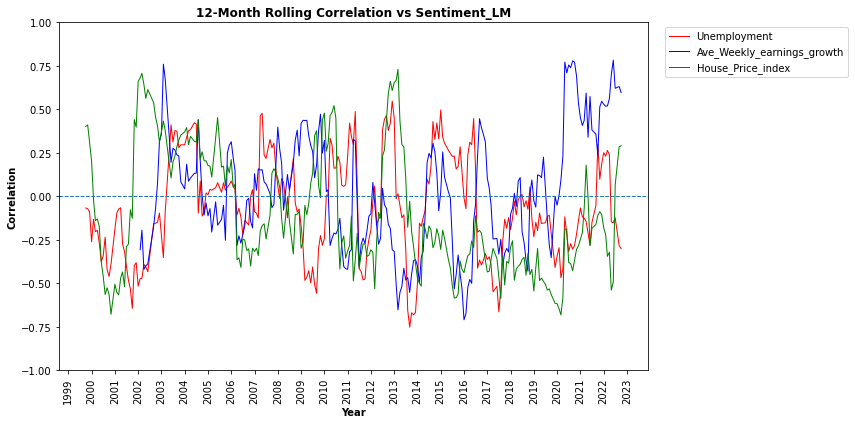

In [133]:
# Selected variables
selected_vars = [
    'Unemployment',
    'Ave_Weekly_earnings_growth',
    'House_Price_index'
]

# Colors corresponding to each variable
colors = ['red', 'blue', 'green']

target = 'Sentiment_LM'
window = 12

plt.figure(figsize=(12, 6))

for col, color in zip(selected_vars, colors):
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col, color=color, linewidth=1)  # Thinner line

plt.title(f"{window}-Month Rolling Correlation vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### Unemployment vs House Price Index

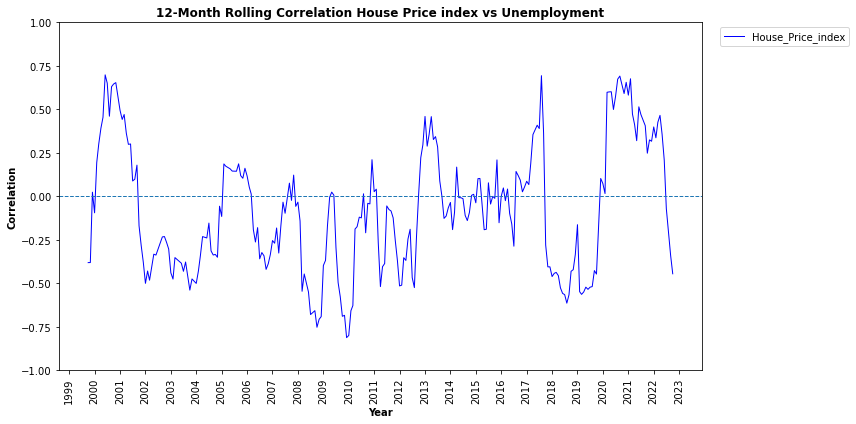

In [134]:
# Selected variables
selected_vars = [
    'House_Price_index'
]

# Colors corresponding to each variable
colors = ['blue']

target = 'Unemployment'
window = 12

plt.figure(figsize=(12, 6))

for col, color in zip(selected_vars, colors):
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col, color=color, linewidth=1)  # Thinner line

plt.title(f"{window}-Month Rolling Correlation House Price index vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### GDP Growth vs Consumer Confidence

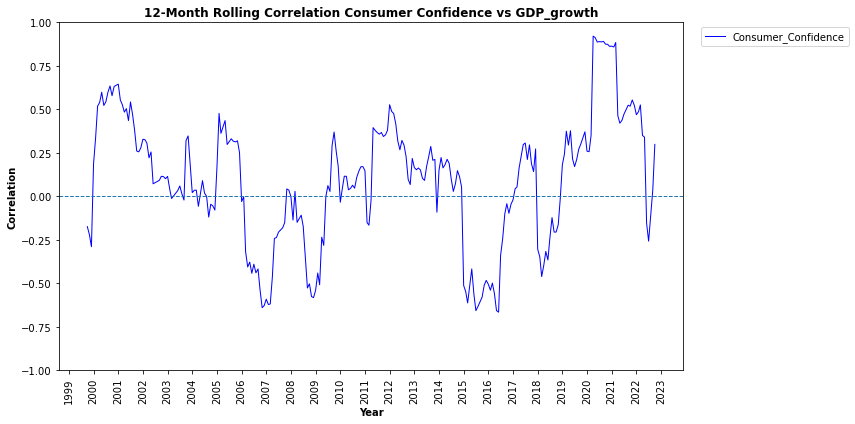

In [135]:
# Selected variables
selected_vars = [
    'Consumer_Confidence'
]

# Colors corresponding to each variable
colors = ['blue']

target = 'GDP_growth'
window = 12

plt.figure(figsize=(12, 6))

for col, color in zip(selected_vars, colors):
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col, color=color, linewidth=1)  # Thinner line

plt.title(f"{window}-Month Rolling Correlation Consumer Confidence vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### Core Inflation vs Unemployment (Phillips curve)

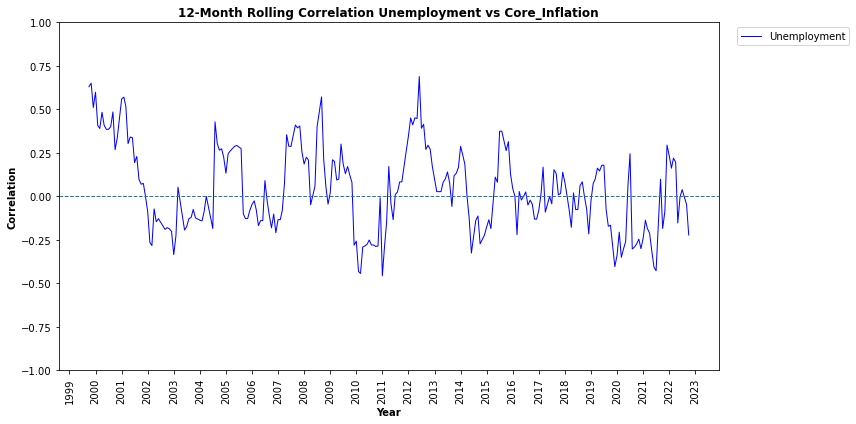

In [136]:
# Selected variables
selected_vars = [
    'Unemployment'
]

# Colors corresponding to each variable
colors = ['blue']

target = 'Core_Inflation'
window = 12

plt.figure(figsize=(12, 6))

for col, color in zip(selected_vars, colors):
    rc = variables_LM[target].rolling(window).corr(variables_LM[col])
    plt.plot(rc, label=col, color=color, linewidth=1)  # Thinner line

plt.title(f"{window}-Month Rolling Correlation Unemployment vs {target}", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Correlation", fontweight='bold')
plt.ylim(-1, 1)

plt.axhline(0, linestyle='--', linewidth=1)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=90)

# Legend in top-right outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
Notebook End